# Logistic Regression for Customer Churn Prediction

## 1. Install Required Libraries. 

In [1]:
# pip install numpy==2.2.0
# pip install pandas==2.2.3
# pip install scikit-learn==1.6.0
# pip install matplotlib==3.9.3

## 2. Import Libraries.

In [ ]:
import pandas as pd 
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import log_loss

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')



## 3.Load the Dataset. 

In [3]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/ChurnData.csv"

churn_df = pd.read_csv(url)
churn_df.head()

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,...,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,...,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,...,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,...,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,...,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0,0.0


## 4. Select Relevant Features. 

In [4]:
churn_df = churn_df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip', 'churn']]

churn_df['churn'] = churn_df['churn'].astype(int)

churn_df.head()

,tenure,age,address,income,ed,employ,equip,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,1
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,0


Explanation

Selecting the features relevant to churn prediction and converting the target variable (churn) to integer format.

## 5. Define Geatures and Target Variable 

In [5]:
X = np.asarray(
	churn_df[
		['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip']
	]
)


y = np.asarray(churn_df['churn'])

print(X[:5],'\n')

print(y[:5])

[[ 11.  33.   7. 136.   5.   5.   0.]
 [ 33.  33.  12.  33.   2.   0.   0.]
 [ 23.  30.   9.  30.   1.   2.   0.]
 [ 38.  35.   5.  76.   2.  10.   1.]
 [  7.  35.  14.  80.   2.  15.   0.]] 

[1 1 0 0 0]


Explanation

Separating the dataset into:

X → Input features.
y → Target variable (customer churn).

## 6. Feature Scaling.

In [6]:
scaler = StandardScaler()

X_norm = scaler.fit_transform(X)
X_norm[:5]

array([[-1.13518441, -0.62595491, -0.4588971 ,  0.4751423 ,  1.6961288 ,
        -0.58477841, -0.85972695],
       [-0.11604313, -0.62595491,  0.03454064, -0.32886061, -0.6433592 ,
        -1.14437497, -0.85972695],
       [-0.57928917, -0.85594447, -0.261522  , -0.35227817, -1.42318853,
        -0.92053635, -0.85972695],
       [ 0.11557989, -0.47262854, -0.65627219,  0.00679109, -0.6433592 ,
        -0.02518185,  1.16316   ],
       [-1.32048283, -0.47262854,  0.23191574,  0.03801451, -0.6433592 ,
         0.53441472, -0.85972695]])

Explanation

Standardizing the numerical features so that they have a mean of 0 and a standard deviation of 1. This improves Logistic Regression performance.

## 7. Split Data into Training and Testing Sets.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.20, random_state=4)

Explanation

Splitting the dataset into:

80% Training Data
20% Testing Data

The random_state ensures reproducible results.

## 8. Train Logistic Regression Model.

In [8]:
LR_model = LogisticRegression()

LR_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Explanation

Training the Logistic Regression model using the training dataset.

## 9. Make Prediction.

In [9]:
y_hat = LR_model.predict(X_test)

y_hat[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0])

Explanation

Predicting whether customers will churn (1) or not churn (0).

## 10. Predict Class Probabilities.

In [10]:
y_hat_prob = LR_model.predict_proba(X_test)

y_hat_prob[:10]

array([[0.74643946, 0.25356054],
       [0.92667894, 0.07332106],
       [0.83442627, 0.16557373],
       [0.94600618, 0.05399382],
       [0.84325532, 0.15674468],
       [0.71448367, 0.28551633],
       [0.77076426, 0.22923574],
       [0.90955642, 0.09044358],
       [0.26152115, 0.73847885],
       [0.94900731, 0.05099269]])

Explanation

Generating probability estimates for each class.

Column 0 → Probability of not churning.

Column 1 → Probability of churning.

## 11. Visualizing Feature Importance.

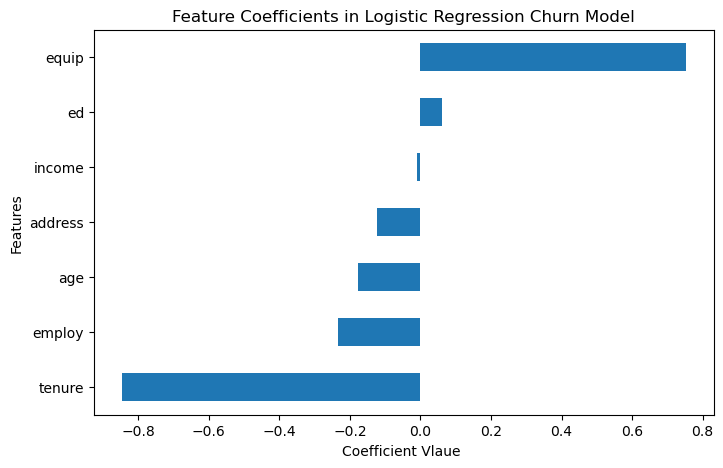

In [ ]:
coefficients = pd.Series(
	LR_model.coef_[0],
   index=churn_df.columns[:-1]
)

coefficients.sort_values().plot(kind='barh', figsize=(8,5))


plt.title('Feature Coefficients in Logistic Regression Churn Model')
plt.xlabel('Coefficient Vlaue ')
plt.ylabel('Features')

plt.show()


Explanation

Displaying the contribution of each feature to the churn prediction model.

- Positive coefficient → Increases churn probability.

- Negative coefficient → Decreases churn probability.

## 12. Evaluation.

In [12]:


# Accuracy
accuracy = accuracy_score(y_test, y_hat)
print(f"Accuracy: {accuracy:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_hat)
print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_hat))

# Log Loss
loss = log_loss(y_test, y_hat_prob)
print(f"\nLog Loss: {loss:.4f}")

Accuracy: 0.7250

Confusion Matrix:
[[25  0]
 [11  4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      1.00      0.82        25
           1       1.00      0.27      0.42        15

    accuracy                           0.72        40
   macro avg       0.85      0.63      0.62        40
weighted avg       0.81      0.72      0.67        40


Log Loss: 0.6258


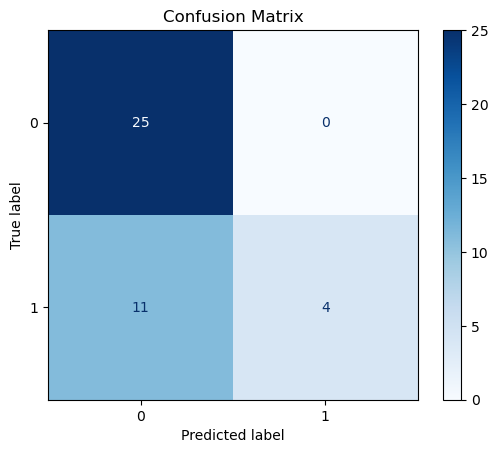

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    LR_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()